In [2]:
!pip install pymysql

In [3]:
# 라이브러리 호출하기
from sqlalchemy import create_engine
import pandas as pd

In [4]:
# MariaDB 연결 설정
username = 'itup_user'    # MariaDB 사용자 이름
password = '!jkjfdk36!'   # MariaDB 비밀번호
host = '211.251.239.92'   # MariaDB 호스트
port = '13306'            # MariaDB 포트
database = 'itup'         # 접속할 데이터베이스 이름

# SQLAlchemy 엔진 생성
engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

In [5]:
# 데이터에 대한 정보가 필요 --> 테이블 정의서

In [6]:
# 데이터 탐색하기: sgg_upjong_cnt
query = '''
select *
from sgg_upjong_cnt
limit 10
'''

sgg_upjong_cnt = pd.read_sql_query(query, engine)
sgg_upjong_cnt

,sgg_cd,sido_nm,sgg_nm,upjong_lnm,upjong_mnm,opn_1,opn_2,opn_3,opn_5,opn_5up
0,2711000000,대구광역시,중구,관광/여가/오락,연극/영화/극장,1,1,3,20,16
1,2711000000,대구광역시,중구,관광/여가/오락,전시/관람,0,0,2,6,12
2,2711000000,대구광역시,중구,관광/여가/오락,PC/오락/당구/볼링등,11,4,7,30,34
3,2711000000,대구광역시,중구,관광/여가/오락,경마/경륜/성인오락,2,0,0,1,2
4,2711000000,대구광역시,중구,관광/여가/오락,요가/단전/마사지,0,0,1,8,6
5,2711000000,대구광역시,중구,관광/여가/오락,놀이/여가/취미,1,1,2,5,6
6,2711000000,대구광역시,중구,관광/여가/오락,무도/유흥/가무,9,2,4,64,46
7,2711000000,대구광역시,중구,관광/여가/오락,스포츠/운동,0,1,1,0,0
8,2711000000,대구광역시,중구,부동산,분양,0,0,12,8,4
9,2711000000,대구광역시,중구,부동산,평가/개발/관리,1,1,2,1,29


In [7]:
query = '''
select upjong_lnm, upjong_mnm, count(sgg_cd) as sgg_cnt
from sgg_upjong_cnt
group by upjong_lnm, upjong_mnm
'''

sgg_upjong_cnt = pd.read_sql_query(query, engine)
sgg_upjong_cnt

,upjong_lnm,upjong_mnm,sgg_cnt
0,관광/여가/오락,PC/오락/당구/볼링등,229
1,관광/여가/오락,경마/경륜/성인오락,173
2,관광/여가/오락,놀이/여가/취미,224
3,관광/여가/오락,무도/유흥/가무,229
4,관광/여가/오락,스포츠/운동,115
...,...,...,...
83,학문/교육,유아교육,229
84,학문/교육,특수교육기관,169
85,학문/교육,학교,229
86,학문/교육,학문교육기타,203


In [8]:
# pandas 노출되는 정보에 대한 설정 변경
pd.set_option('display.max_rows', 100)

In [9]:
query = '''
select upjong_lnm, upjong_mnm, count(sgg_cd) as sgg_cnt
from sgg_upjong_cnt
group by upjong_lnm, upjong_mnm
'''

sgg_upjong_cnt = pd.read_sql_query(query, engine)
sgg_upjong_cnt

,upjong_lnm,upjong_mnm,sgg_cnt
0,관광/여가/오락,PC/오락/당구/볼링등,229
1,관광/여가/오락,경마/경륜/성인오락,173
2,관광/여가/오락,놀이/여가/취미,224
3,관광/여가/오락,무도/유흥/가무,229
4,관광/여가/오락,스포츠/운동,115
5,관광/여가/오락,연극/영화/극장,205
6,관광/여가/오락,요가/단전/마사지,208
7,관광/여가/오락,전시/관람,229
8,부동산,부동산관련서비스,225
9,부동산,부동산임대,221


In [10]:
# 데이터 탐색하기: 업종중분류 = '커피점/카페'인 경우만 데이터를 추출해서 보기
query = '''
select *
from sgg_upjong_cnt
where upjong_mnm = '커피점/카페'
'''

sgg_upjong_cnt = pd.read_sql_query(query, engine)
sgg_upjong_cnt

,sgg_cd,sido_nm,sgg_nm,upjong_lnm,upjong_mnm,opn_1,opn_2,opn_3,opn_5,opn_5up
0,2711000000,대구광역시,중구,음식,커피점/카페,154,104,77,156,266
1,2714000000,대구광역시,동구,음식,커피점/카페,110,74,73,134,154
2,2717000000,대구광역시,서구,음식,커피점/카페,36,37,34,67,139
3,2720000000,대구광역시,남구,음식,커피점/카페,73,47,42,78,77
4,2723000000,대구광역시,북구,음식,커피점/카페,146,97,84,137,158
...,...,...,...,...,...,...,...,...,...,...
224,2823700000,인천광역시,부평구,음식,커피점/카페,134,96,121,187,198
225,2824500000,인천광역시,계양구,음식,커피점/카페,68,60,82,98,70
226,2826000000,인천광역시,서구,음식,커피점/카페,146,96,122,155,146
227,2871000000,인천광역시,강화군,음식,커피점/카페,56,19,13,41,51


In [11]:
# 가설1: 시군구마다 '커피점/카페' 업종의 total 상가수가 적은 지역은 경쟁률이 낮다고 할 수 있을까?
# total = opn_1 +...+ opn_5 + opn_5up
# total 기준으로 오름차순 정렬을 해본다면 상위에 나오는 시군구에는 카페수가 적은 시군구일 것이다.

query = '''
select *, opn_1 + opn_2 + opn_3 + opn_5 + opn_5up as total
from sgg_upjong_cnt
where upjong_mnm = '커피점/카페'
order by total
'''

sgg_upjong_cnt = pd.read_sql_query(query, engine)
sgg_upjong_cnt

,sgg_cd,sido_nm,sgg_nm,upjong_lnm,upjong_mnm,opn_1,opn_2,opn_3,opn_5,opn_5up,total
0,4794000000,경상북도,울릉군,음식,커피점/카페,3,1,1,4,7,16
1,4572000000,전라북도,진안군,음식,커피점/카페,3,2,4,4,6,19
2,4574000000,전라북도,장수군,음식,커피점/카페,1,2,2,4,12,21
3,4776000000,경상북도,영양군,음식,커피점/카페,2,2,3,7,14,28
4,4691000000,전라남도,신안군,음식,커피점/카페,2,4,4,10,17,37
...,...,...,...,...,...,...,...,...,...,...,...
224,4812000000,경상남도,창원시,음식,커피점/카페,397,229,392,436,315,1769
225,4128000000,경기도,고양시,음식,커피점/카페,441,270,418,530,328,1987
226,4111000000,경기도,수원시,음식,커피점/카페,426,264,388,526,388,1992
227,4113000000,경기도,성남시,음식,커피점/카페,429,257,380,547,396,2009


In [12]:
# 가설2: 카페당 인구수(인구수/카페)라는 개념을 통해서 경쟁률을 재정의할 필요가 있지 않을까?
query = '''
select *
from sgg_upjong_cnt
limit 3
'''

sgg_upjong_cnt = pd.read_sql_query(query, engine)
sgg_upjong_cnt
# sgg_pop_cnt > pop_total: 시군구 내 총 주민등록인구수
# sgg_upjong_cnt > total: 시군구 내 카페/커피점 업종의 상가수

# 상가수 / 인구수: 새로운 경쟁률 지표

,sgg_cd,sido_nm,sgg_nm,upjong_lnm,upjong_mnm,opn_1,opn_2,opn_3,opn_5,opn_5up
0,2711000000,대구광역시,중구,관광/여가/오락,연극/영화/극장,1,1,3,20,16
1,2711000000,대구광역시,중구,관광/여가/오락,전시/관람,0,0,2,6,12
2,2711000000,대구광역시,중구,관광/여가/오락,PC/오락/당구/볼링등,11,4,7,30,34


In [13]:
# 상가수 데이터 탐색하기: sgg_upjong_cnt
query = ''' 
select * 
      , opn_1 + opn_2 + opn_3 + opn_5 + opn_5up as total 
from   sgg_upjong_cnt 
limit 3
'''

df = pd.read_sql_query(query, engine)
df 

,sgg_cd,sido_nm,sgg_nm,upjong_lnm,upjong_mnm,opn_1,opn_2,opn_3,opn_5,opn_5up,total
0,2711000000,대구광역시,중구,관광/여가/오락,연극/영화/극장,1,1,3,20,16,41
1,2711000000,대구광역시,중구,관광/여가/오락,전시/관람,0,0,2,6,12,20
2,2711000000,대구광역시,중구,관광/여가/오락,PC/오락/당구/볼링등,11,4,7,30,34,86


In [14]:
# 데이터 결합하기: join
query = ''' 
select  up.sgg_cd 
      , up.sido_nm 
      , up.sgg_nm 
      , up.opn_1 
      , up.opn_2 
      , up.opn_3 
      , up.opn_5 
      , up.opn_5up 
      , up.opn_1 + up.opn_2 + up.opn_3 + up.opn_5 + up.opn_5up as total 
      , pop.pop_total
from    sgg_upjong_cnt as up 
        inner join sgg_pop_cnt as pop 
        on up.sgg_cd = pop.sgg_cd 
where   up.upjong_mnm = '커피점/카페'        
'''

df = pd.read_sql_query(query, engine)
df 

,sgg_cd,sido_nm,sgg_nm,opn_1,opn_2,opn_3,opn_5,opn_5up,total,pop_total
0,2711000000,대구광역시,중구,154,104,77,156,266,757,79401
1,2714000000,대구광역시,동구,110,74,73,134,154,545,351291
2,2717000000,대구광역시,서구,36,37,34,67,139,313,184372
3,2720000000,대구광역시,남구,73,47,42,78,77,317,150501
4,2723000000,대구광역시,북구,146,97,84,137,158,622,439489
...,...,...,...,...,...,...,...,...,...,...
224,2823700000,인천광역시,부평구,134,96,121,187,198,736,524640
225,2824500000,인천광역시,계양구,68,60,82,98,70,378,312680
226,2826000000,인천광역시,서구,146,96,122,155,146,665,538596
227,2871000000,인천광역시,강화군,56,19,13,41,51,180,68896


In [15]:
# 데이터 결합하기: join > total / pop_total 새로운 경쟁률 지표 만들기
#                >> total / pop_total: 인구 1명당 카페수
#                >> total / (pop_total/10000): 인구 10000명당 카페수
query = ''' 
select  up.sgg_cd 
      , up.sido_nm 
      , up.sgg_nm 
      , up.opn_1 / (pop_total/10000) as opn_1_per_pop
      , up.opn_2 / (pop_total/10000) as opn_2_per_pop
      , up.opn_3 / (pop_total/10000) as opn_3_per_pop
      , up.opn_5 / (pop_total/10000) as opn_5_per_pop
      , up.opn_5up / (pop_total/10000) as opn_5up_per_pop
      , (up.opn_1 + up.opn_2 + up.opn_3 + up.opn_5 + up.opn_5up) / (pop_total/10000) as total_per_pop 
from    sgg_upjong_cnt as up 
        inner join sgg_pop_cnt as pop 
        on up.sgg_cd = pop.sgg_cd 
where   up.upjong_mnm = '커피점/카페'        
'''

df = pd.read_sql_query(query, engine)
df 

,sgg_cd,sido_nm,sgg_nm,opn_1_per_pop,opn_2_per_pop,opn_3_per_pop,opn_5_per_pop,opn_5up_per_pop,total_per_pop
0,2711000000,대구광역시,중구,19.3952,13.0981,9.6976,19.6471,33.5008,95.3388
1,2714000000,대구광역시,동구,3.1313,2.1065,2.0780,3.8145,4.3838,15.5142
2,2717000000,대구광역시,서구,1.9526,2.0068,1.8441,3.6340,7.5391,16.9765
3,2720000000,대구광역시,남구,4.8505,3.1229,2.7907,5.1827,5.1162,21.0630
4,2723000000,대구광역시,북구,3.3220,2.2071,1.9113,3.1173,3.5951,14.1528
...,...,...,...,...,...,...,...,...,...
224,2823700000,인천광역시,부평구,2.5541,1.8298,2.3063,3.5643,3.7740,14.0287
225,2824500000,인천광역시,계양구,2.1747,1.9189,2.6225,3.1342,2.2387,12.0890
226,2826000000,인천광역시,서구,2.7108,1.7824,2.2651,2.8779,2.7108,12.3469
227,2871000000,인천광역시,강화군,8.1282,2.7578,1.8869,5.9510,7.4025,26.1263


In [16]:
df.describe()

,opn_1_per_pop,opn_2_per_pop,opn_3_per_pop,opn_5_per_pop,opn_5up_per_pop,total_per_pop
count,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000
mean,4.246481,2.535903,2.365658,4.000848,5.097344,18.246234
std,2.463947,1.712164,1.393923,2.312171,3.676883,10.049308
min,0.430600,0.563100,0.293800,1.515400,0.854400,6.944300
25%,2.781600,1.687800,1.498400,2.794800,2.710800,13.235400
50%,3.806300,2.240500,2.066000,3.497400,4.139900,16.370300
75%,4.975100,2.843100,2.975500,4.459500,6.558200,20.745600
max,19.395200,13.098100,9.697600,19.647100,33.500800,95.338800


## 데이터 시각화 하기: 히트맵

In [17]:
df.head()

,sgg_cd,sido_nm,sgg_nm,opn_1_per_pop,opn_2_per_pop,opn_3_per_pop,opn_5_per_pop,opn_5up_per_pop,total_per_pop
0,2711000000,대구광역시,중구,19.3952,13.0981,9.6976,19.6471,33.5008,95.3388
1,2714000000,대구광역시,동구,3.1313,2.1065,2.0780,3.8145,4.3838,15.5142
2,2717000000,대구광역시,서구,1.9526,2.0068,1.8441,3.6340,7.5391,16.9765
3,2720000000,대구광역시,남구,4.8505,3.1229,2.7907,5.1827,5.1162,21.0630
4,2723000000,대구광역시,북구,3.3220,2.2071,1.9113,3.1173,3.5951,14.1528


In [18]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager, rc

# 한글 폰트 설정
rc('font', family='Malgun Gothic')

In [19]:
# 데이터 시각화를 위해서 데이터프레임 재배치
df.columns

Index(['sgg_cd', 'sido_nm', 'sgg_nm', 'opn_1_per_pop', 'opn_2_per_pop',
       'opn_3_per_pop', 'opn_5_per_pop', 'opn_5up_per_pop', 'total_per_pop'],
      dtype='object')

In [20]:
df_vis = df[['sido_nm', 'sgg_nm', 'opn_1_per_pop', 'opn_2_per_pop',
       'opn_3_per_pop', 'opn_5_per_pop', 'opn_5up_per_pop', 'total_per_pop']]

df_vis = df_vis.set_index(['sido_nm', 'sgg_nm'])
df_vis.head()

opn_1_per_pop  opn_2_per_pop  opn_3_per_pop  opn_5_per_pop  \
sido_nm sgg_nm                                                               
대구광역시   중구            19.3952        13.0981         9.6976        19.6471   
        동구             3.1313         2.1065         2.0780         3.8145   
        서구             1.9526         2.0068         1.8441         3.6340   
        남구             4.8505         3.1229         2.7907         5.1827   
        북구             3.3220         2.2071         1.9113         3.1173   

                opn_5up_per_pop  total_per_pop  
sido_nm sgg_nm                                  
대구광역시   중구              33.5008        95.3388  
        동구               4.3838        15.5142  
        서구               7.5391        16.9765  
        남구               5.1162        21.0630  
        북구               3.5951        14.1528

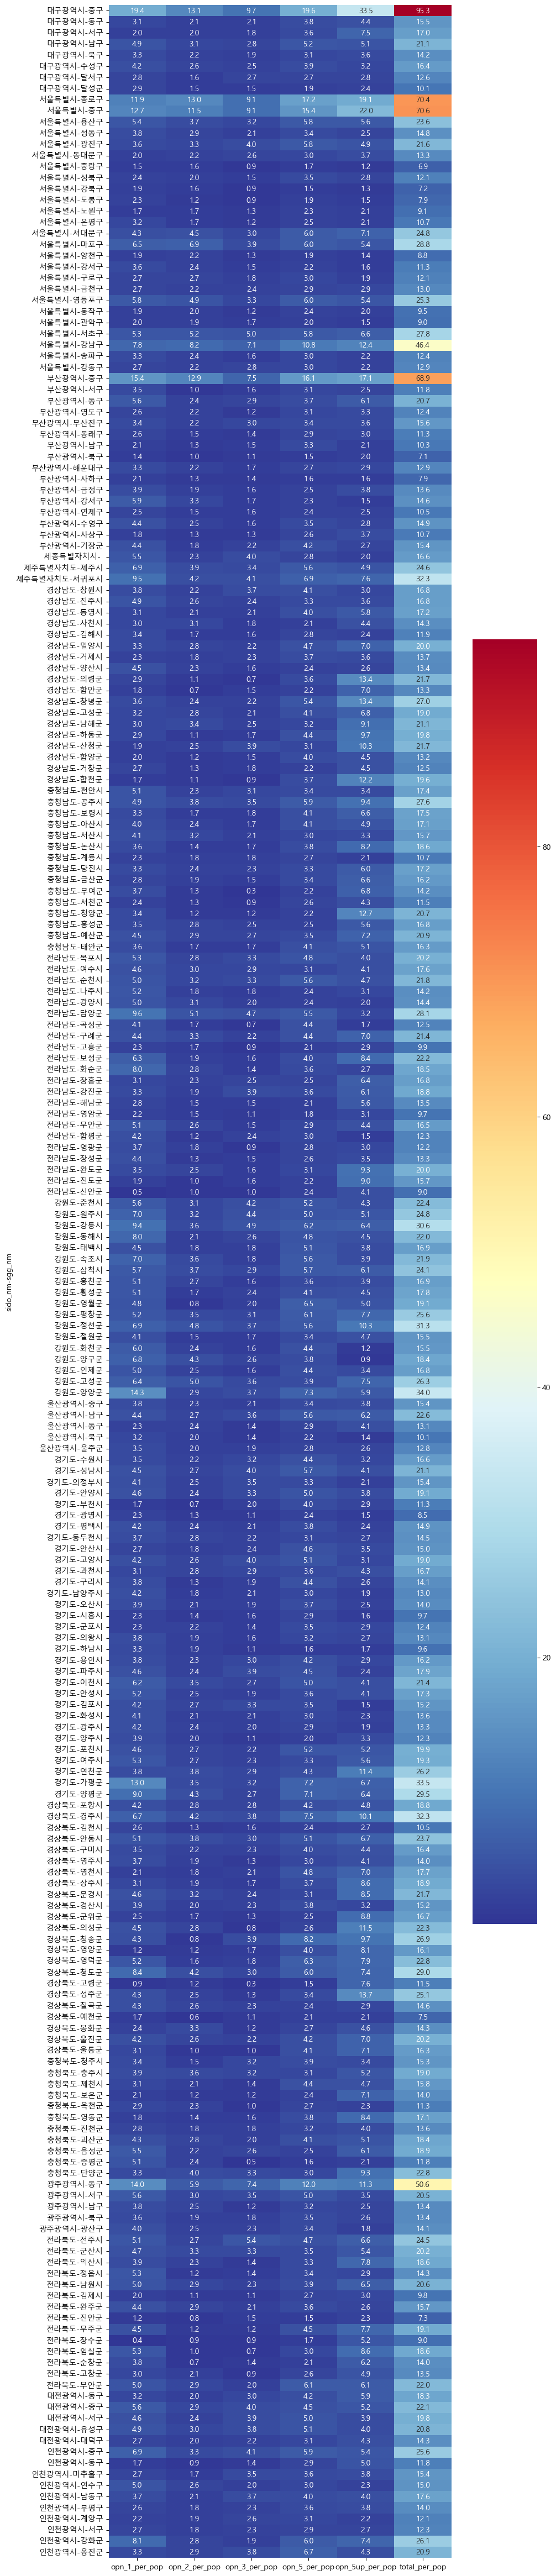

In [22]:
# 그래프 크기 설정 
plt.figure(figsize = (10, 60))

# 히트맵 그래프 그리기 
sns.heatmap(data = df_vis, annot = True, fmt='.1f', cmap='RdYlBu_r')

# 그래프 그리기 
plt.show()